# Adding a new scheme

A **scheme** owns the *iteration policy*: how many steps to take, whether to
accept or reject one, how to damp, and when to stop. The per-iteration
mathematics belongs to the analysis instead — see
[Adding a new analysis](adding_an_analysis.ipynb).

Roughly:

| | owns |
| --- | --- |
| analysis | one step: ensemble + predictions -> update |
| scheme | the loop around it: accept/reject, damping, stopping |
| ensemble | the data: state realisations, observations, simulator |

## What you inherit

Concrete schemes subclass `AssimilationScheme`, one class holding both the
algorithm core and the run workflow (artifact saving, diagnostics, outlier
handling):

In [1]:
from pipt.update_schemes.core import AssimilationScheme

for c in AssimilationScheme.__mro__:
    print("   ", c.__name__)

    AssimilationScheme
    AnalysisBindingMixin
    RestartMixin
    ABC
    object


That one class gives you the iteration loop, convergence bookkeeping, restart
handling, the run table, the result object, analysis binding, the ensemble
façade, and the artifacts a run writes.

## What the base calls, and when

`run_assimilation()` drives this sequence. Everything marked **▸** is yours to
override; each already does something sensible, so you override only what you
want to change.

```
run_assimilation()
│
├─ run_forecast(prior)              forecast the prior ensemble
│    └─ after_forecast(state)     ▸ may resample members; returns state
├─ record_prior_score()             scores the prior, through your score()
├─ after_prior_forecast()         ▸ prior QA/QC, prior artifacts
│
├─ while iteration < maxiter:
│    ├─ update_step()             ▸ REQUIRED — returns a StepReport
│    ├─ log_update()                one row per accepted iteration
│    ├─ after_accepted_iteration()▸ savedata, QA/QC — accepted steps only
│    ├─ check_misfit_convergence()  generic; on unless misfit_tol = 0
│    ├─ check_state_convergence()   generic; on unless step_tol   = 0
│    └─ check_convergence()       ▸ your own stopping criterion
│
└─ after_loop(converged)          ▸ posterior, stop reason, summary
```

The two generic criteria are **on by default** (`misfit_tol=0.01`,
`step_tol=1e-8`). Every shipped scheme passes `0.0` for both, because it
decides for itself in `check_convergence()` — do the same unless you want
them, or a scheme that merely stops moving the state will report itself
converged.

`update_step()` is the only one you must write. **One call is one iteration.**
If your scheme retries — backtracking a step length, re-damping, resampling —
that loop goes *inside* `update_step()`, the way `EnOpt.update_step` in popt
backtracks over its own step length before returning. LM-EnRML and GN-EnRML
iterate their λ and γ there.

The `StepReport` you return then describes the iteration as a whole. Set
`accepted=False` when you have run out of attempts: the loop takes that as
"this scheme has nothing better to offer", leaves the state uncommitted and
stops the run — it will not ask again for a step you just said you could not
find.

If you stop on your own criterion, set `self.conv_msg` when you do — the two
generic checks set it themselves, but yours is the only thing that can explain
your own stop, and a run that ends without one reports no stopping reason.

### What is *not* on that list

There is no `after_analysis` hook on the base. That point exists only *inside*
`update_step()`, and the base does not dictate the shape of your step — it
calls `update_step()` and nothing within it. `AssimilationWorkflowMixin`
declares and implements one for schemes that inherit `AssimilationScheme`, and
the scheme calls it from its own step, as the example below does.

## What `update_step()` must report

The base does not inspect *how* you take a step, but it needs to know what the
step produced. That is the return value:

```python
@dataclass(slots=True)
class StepReport:
    accepted: bool                    # keep this step, or retry?
    state:    Any                     # the state this attempt produced
    misfit:   np.ndarray              # per-realisation data misfit, as of now
    why_stop: dict | None = None      # merged into result.why_stop
```

The three required fields are positional, so leaving one out is a `TypeError`
where you wrote it — not a `None` surfacing three iterations later. The loop
commits `state` when `accepted`, and discards it otherwise.

The loop derives the scalars from the one array:

```python
self.ensemble_misfit  = misfit
self.data_misfit_mean = float(misfit.mean())
self.data_misfit_std  = float(misfit.std())
```

so those three can no longer drift apart, which they could when each scheme
assigned them separately.

**"As of now" is deliberate.** A scheme that rejects a step reports the misfit
it wants the loop to record — for LM-EnRML that is the *last accepted* one,
restored when it backs off, because that is what the next comparison is
against.

### Still yours to do

| do | why |
| --- | --- |
| `self.prev_data_misfit_mean = self.data_misfit_mean` before reporting | the relative-change test compares against it |
| — | the base records the prior misfit for you, from `score()` |
| pass the trial state to `self.run_forecast(state)` | it returns the state actually forecast |
| call `self.after_analysis()` | the workflow hook between analysis and forecast |

```python
enX_trial = self.enX + step               # a local value; nothing is parked
enX_trial = self.run_forecast(enX_trial)  # may come back with members resampled
return StepReport(accepted=True, state=enX_trial, misfit=misfit)
```

You do **not** commit the state, or set `self.step_accepted` — the loop does
both from the report, committing `state` when `accepted` and discarding it
otherwise. The trial state never touches the ensemble at all: it is a local
value you pass to `run_forecast` and hand back in the report.

`data_misfit_mean`, `data_misfit_std` and `ensemble_misfit` are likewise
derived from the report, so you need not maintain them. But the loop only
does that *after* `update_step` returns, so if you want a value **during** the
step — to decide whether to accept, as LM-EnRML does — compute it yourself
with `self.score()`. The loop then records the same number.

The run table is the loop's too: it logs one row per accepted iteration, so
you do not call `log_update()` yourself. Override `log_columns()` if you want
your control parameter in it.

### One definition of the misfit: `score()`

`score(pred_data=None)` returns the per-realisation data misfit of a forecast.
The base implements the one every shipped scheme uses,

```python
at.calc_objectivefun(self.enObs, self.pred_data.matrix, self.cov_data)
```

so a scheme that binds `enObs` and `cov_data` in `__init__` — as the example
below does — gets it for nothing. Override it only if you score differently:
ES-MDA scores against its *un-inflated* perturbations, the EnKF family against
the Cholesky factor rather than the full covariance.

It is called in two places, which is the reason it exists:

- **the prior**, by `record_prior_score()`, after the prior forecast and
  before the loop. That is what makes `prior_data_misfit_mean` the *prior's*
  misfit — computing it on the first pass through `update_step` instead would
  record the misfit after one step and label it the prior.
- **every attempt inside your step**, wherever you need a number to decide on.

## The façade rule

Reads of ensemble state go through the scheme; **writes go to the ensemble
explicitly**:

```python
x = self.enX                       # read  -- a property on the scheme
self.ensemble.list_states = [...]  # write -- explicit, via the ensemble
```

A read-only property has no setter, so a stray `self.enX = ...` raises rather
than silently creating a copy the forecast never sees.

The state you are *working on* is not written to the ensemble at all. A trial
state stays a local value: you pass it to `run_forecast` and return it in the
`StepReport`, and the loop commits it to `ensemble.enX` if the step was
accepted. Four names are the
exception and *do* have setters, because a scheme may legitimately compute
them itself: `cov_data`, `scale_data`, `proj`, `Am`.

## A worked example

A smoother that takes a fixed fraction of each analysis step and never
rejects — simpler than LM-EnRML, but a complete scheme.

In [2]:
from copy import deepcopy
import numpy as np
import pipt.misc_tools.analysis_tools as at
from geostat.decomp import Cholesky
from pipt.ensembles import AssimilationEnsemble
from pipt.update_schemes.core import AssimilationScheme, StepReport
from pipt.update_schemes.analysis.approx import approx_update


class FixedStepSmoother(AssimilationScheme):
    """Iterative smoother taking a fixed fraction of each analysis step."""

    ENSEMBLE_CLASS = AssimilationEnsemble
    COMPATIBLE_ANALYSES = {"approx": approx_update}

    def __init__(self, keys_da, keys_en, sim, analysis=None):

        # Initialize the ensemble class
        ensemble = self.ENSEMBLE_CLASS(keys_da, keys_en, sim)

        # Initialize the base class
        super().__init__(
            ensemble, 
            misfit_tol=0.0, # zero tolerances switch off generic criteria
            step_tol=0.0    # zero tolerances switch off generic criteria
        )

        # Set up the analysis method for this scheme (will be approx_update)
        self.bind_analysis(self.resolve_analysis(analysis, keys_da))

        # Set up the scheme-specific parameters
        opts = self.keys_da.get("iteration", {})
        self.maxiter      = opts.get("max_iter", 5)
        self.gamma        = opts.get("gamma", 0.5)   # fixed step length
        self.lam          = 0.0   # no damping -- but the analysis reads it
        self.trunc_energy = self.keys_da.get("energy", 0.98)
        self.iteration    = self.ensemble.iteration = 0
        self.prev_data_misfit_mean = None

        # The ensemble does not build these; the scheme owns them.
        self.ensemble.prior_enX      = deepcopy(self.enX)
        self.ensemble.list_states    = list(self.idX)
        self.ensemble.list_datatypes = self.keys_da["datatype"]
        self.vecObs = self.obs_vector
        self.enObs = self.ensemble.perturb_observations(self.vecObs)
        self.cov_data = self.obs_variance

    # No score() override: the base's default is
    # calc_objectivefun(enObs, pred_data, cov_data), and __init__ bound both
    # of those above. The base scores the prior with it before the loop, and
    # update_step() below calls it for each iteration.

    def update_step(self) -> StepReport:
        # Prediction ensemble matrix
        self.enPred = self.pred_data.matrix

        # Calulate step
        step = self.update(
            enX=self.enX, 
            enY=self.enPred, 
            enE=self.enObs
        )

        # A local proposal -- nothing is written to the ensemble until the
        # loop commits what we report.
        enX_trial = self.enX + self.gamma * step
        self.after_analysis()

        # Forecast it. run_forecast hands back the state actually used (can be resampled by outlier replacement).
        enX_trial = self.run_forecast(enX_trial)

        # Score the forecast -- the same score() the base used on the prior
        self.prev_data_misfit_mean = self.data_misfit_mean
        data_misfit = self.score()

        return StepReport(
            accepted=True, 
            state=enX_trial,
            misfit=data_misfit
        )

    def log_columns(self, prior_run: bool = False) -> dict:
        """One trailing column in the run table: our fixed step length.

        ES-MDA reports its inflation factor here and LM-EnRML its damping;
        the rest of the row -- iteration, status, misfit, change -- is the
        base's, which also decides when to log one.
        """
        return {"γ": self.gamma}

    def check_convergence(self) -> bool:
        return False  # Run the full schedule (all iterations)

print("defined", FixedStepSmoother.__name__)

defined FixedStepSmoother


## A case to run it on

In [3]:
import os, tempfile
from copy import deepcopy
import numpy as np
from misc.structures import PETDataFrame
from simulator.simple_models import lin_1d

# A 60-cell state observed at every 5th position. Pure numpy, runs instantly.
STATE_SIZE = 60
CFG_SIM = {"reporttype": "position", "reportpoint": list(range(5, STATE_SIZE, 5)),
           "datatype": ["value"],
           # NOTE: >1 is deliberate. lin_1d returns a shared internal object from
           # run_fwd_sim, so a sequential run aliases every member onto the same
           # prediction and the ensemble collapses to zero spread.
           "parallel": 4}

CFG_ENS = {"ne": 50, "state": "x",
           "prior_x": {"vario": "sph", "mean": [0.0] * STATE_SIZE, "var": 1.0,
                       "range": 20.0, "aniso": 1.0, "angle": 0.0,
                       "grid": [STATE_SIZE, 1]}}

def cfg_da(analysis, **iteration):
    # Only what FixedStepSmoother actually reads. The Levenberg-Marquardt
    # keys (lambda, lambda_factor, ...) belong to schemes that damp; this one
    # takes a fixed fraction of each step instead.
    it = {"max_iter": 20, "gamma": 0.5}
    it.update(iteration)
    return {"scheme": "custom", "analysis": analysis, "energy": 0.95,
            "obsname": "position", "data": "true_data.pkl", "datavar": "var.pkl",
            "iteration": it}

def make_truth():
    """Write the synthetic observations the schemes below assimilate.

    Returns the true state, so the plots can compare against it.
    """
    np.random.seed(10)
    sim = lin_1d(CFG_SIM); sim.setup_fwd_run()
    state = {"x": np.random.multivariate_normal(np.zeros(STATE_SIZE), np.eye(STATE_SIZE))}
    pred = PETDataFrame.from_records(sim.run_fwd_sim(state, 0), index=CFG_SIM["reportpoint"])
    data, var = pred.copy(), pred.copy()
    for c in data.columns:
        data[c] = data[c].apply(np.squeeze)
        var[c] = var[c].apply(lambda _: ["abs", 1.0])
    data.to_pickle("true_data.pkl"); var.to_pickle("var.pkl")
    return state["x"]

os.chdir(tempfile.mkdtemp())   # keep run artifacts out of the docs tree
TRUE_STATE = make_truth()
OBS_AT = CFG_SIM["reportpoint"]
print(f"case ready: {STATE_SIZE}-cell state, {len(OBS_AT)} observations, ne={CFG_ENS['ne']}")

case ready: 60-cell state, 11 observations, ne=50


In [4]:
np.random.seed(10)
res = FixedStepSmoother.assimilate(cfg_da("approx"), deepcopy(CFG_ENS),
                                   lin_1d(CFG_SIM), analysis="approx")
print(f"misfit {res.prior_data_misfit:7.2f} -> {res.data_misfit:6.2f}"
      f"   iterations={res.nit}")
print("stopped because:", res.message)

2026-08-28│14:56:29 :  =========== Running Data Assimilation - CUSTOM ===========


  0%|                                                                              | 0/50 [00:00<?, ?member/s]

2026-08-28│14:56:29 : 


2026-08-28│14:56:29 :  ┌─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐


2026-08-28│14:56:29 :  │  Iteration  │   Status    │ Data Misfit │ Change (%)  │      γ      │


...

2026-08-28│14:56:31 : 


2026-08-28│14:56:31 : Maximum iterations reached without convergence.


2026-08-28│14:56:31 :  
 Convergence was met. Obj. function reduced from 30.0 to 6.2


2026-08-28│14:56:31 :  Assimilation finished after 20 iteration(s): Maximum number of iterations reached


misfit   29.98 ->   6.24   iterations=20
stopped because: Maximum number of iterations reached


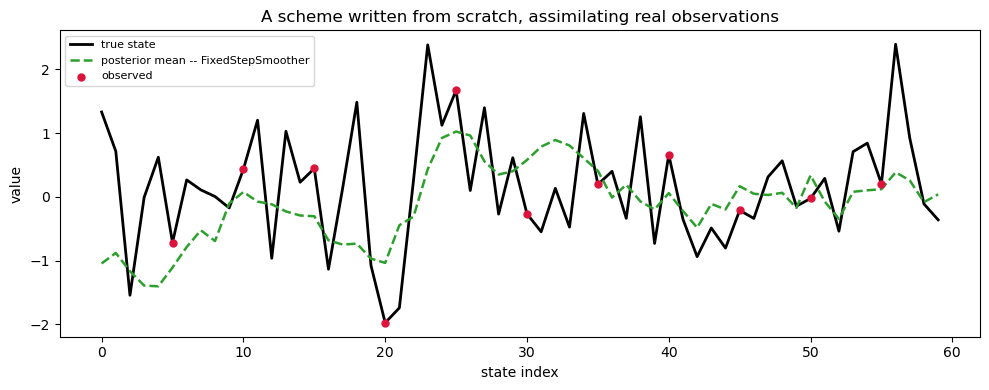

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(TRUE_STATE, "k-", lw=2, label="true state")
ax.plot(np.asarray(res.x).mean(axis=-1), "--", lw=1.8, c="tab:green",
        label="posterior mean -- FixedStepSmoother")
ax.scatter(OBS_AT, TRUE_STATE[OBS_AT], c="crimson", zorder=5, s=25, label="observed")
ax.set_xlabel("state index"); ax.set_ylabel("value")
ax.set_title("A scheme written from scratch, assimilating real observations")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Making it available from a config

The class works directly, as above. To reach it the way the built-in schemes
are reached — by name from a config's `scheme` / `analysis` keys — register
the combination:

In [6]:
from pipt.update_schemes import registry

registry.register_scheme("fixedstep", "approx", FixedStepSmoother, overwrite=True)

ctor = registry.get_scheme("fixedstep", "approx")
print("registry resolves to:", ctor.func.__name__ if hasattr(ctor, "func") else ctor)
print("('fixedstep', 'approx') in available_schemes():",
      ("fixedstep", "approx") in registry.available_schemes())

registry resolves to: <class '__main__.FixedStepSmoother'>
('fixedstep', 'approx') in available_schemes(): True


## Checklist

**Wiring**

1. Subclass `AssimilationScheme`.
2. Set `ENSEMBLE_CLASS` and `COMPATIBLE_ANALYSES`.
3. In `__init__`: build the ensemble, call `super().__init__(...)`, then
   `bind_analysis(resolve_analysis(...))`. Set what the analyses read
   (`lam`, `trunc_energy`) and what the ensemble does not build for you
   (`cov_data`, the observation vector).

**The step**

4. Implement `update_step()`, returning
   `StepReport(accepted=..., state=..., misfit=...)` — `misfit` being the
   per-realisation array. One call is one iteration: any retry loop over a
   step length or damping parameter belongs inside it.
5. Inside it: call `self.after_analysis()`, pass the trial state to
   `self.run_forecast(state)`, and report the state it hands back — that is
   the one with any resampled members.
6. Set `self.prev_data_misfit_mean` before reporting the new misfit; the
   relative-change test compares against it.

**Easy to forget**

7. Bind `enObs` and `cov_data` in `__init__` so the base's `score()` works —
   that is what makes `prior_data_misfit_mean` the *prior's* misfit, since the
   base scores the prior with it before the loop. Score some other way and
   `score()` is the one method to override; leave the scheme with nothing to
   score and the run dies in the closing summary with `NoneType > float`.
8. Override `check_convergence()` if the scheme stops on its own criterion,
   and set `self.conv_msg` when it fires — otherwise the run reports no
   stopping reason.

**Optional**

9. Override `log_columns()` to add your control parameter to the run table,
   the way ES-MDA reports `α` and LM-EnRML `λ`. The rows themselves are the
   loop's job — one per accepted iteration — so there is no `log_update()`
   call for you to make.
10. `register_scheme(...)` if it should be reachable from a config.

You never set `step_accepted` and never commit the state — the loop does both
from the report, along with `data_misfit_mean`, `data_misfit_std` and
`ensemble_misfit` once `update_step` returns.